In [ ]:
from pathlib import Path
import runpy

def _find_notebook_bootstrap(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        direct = candidate / "notebooks" / "_bootstrap.py"
        if direct.exists():
            return direct
        nested = candidate / "abstractgraph-generative" / "notebooks" / "_bootstrap.py"
        if nested.exists():
            return nested
    raise FileNotFoundError("Could not locate notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_find_notebook_bootstrap(Path.cwd())))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]


# DiGress Generation on Artificial Graphs

This notebook mirrors the artificial-graph dataset setup used in the GRAN workflow and fits `DiGressGraphGenerator` on the resulting NetworkX graphs.

In [1]:
%config InlineBackend.figure_format = 'retina'

import random
import sys
from pathlib import Path

import numpy as np

ROOT = repo_root
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from abstractgraph import ArtificialGraphDatasetConstructor
from abstractgraph_generative.digress_graph_generator import DiGressGraphGenerator
from abstractgraph.display import display_graphs

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [2]:
def offset_neg_graphs(graphs, targets, offset=10):
    out_graphs = []
    for graph, target in zip(graphs, targets):
        if target == 0:
            for u in graph.nodes():
                graph.nodes[u]['label'] += offset
        out_graphs.append(graph.copy())
    return out_graphs, targets


def select_pos_neg(sampled_graphs, sampled_targets, n_lines=3, n_graphs_per_line=12):
    import random
    k = n_graphs_per_line * n_lines
    pos_candidates = [g for g, t in zip(sampled_graphs, sampled_targets) if t == 1]
    neg_candidates = [g for g, t in zip(sampled_graphs, sampled_targets) if t != 1]
    pos_graphs = random.sample(pos_candidates, k=min(k, len(pos_candidates)))
    neg_graphs = random.sample(neg_candidates, k=min(k, len(neg_candidates)))
    return pos_graphs, neg_graphs

#graphs: 7887
#positive: 3972
#negative: 3915


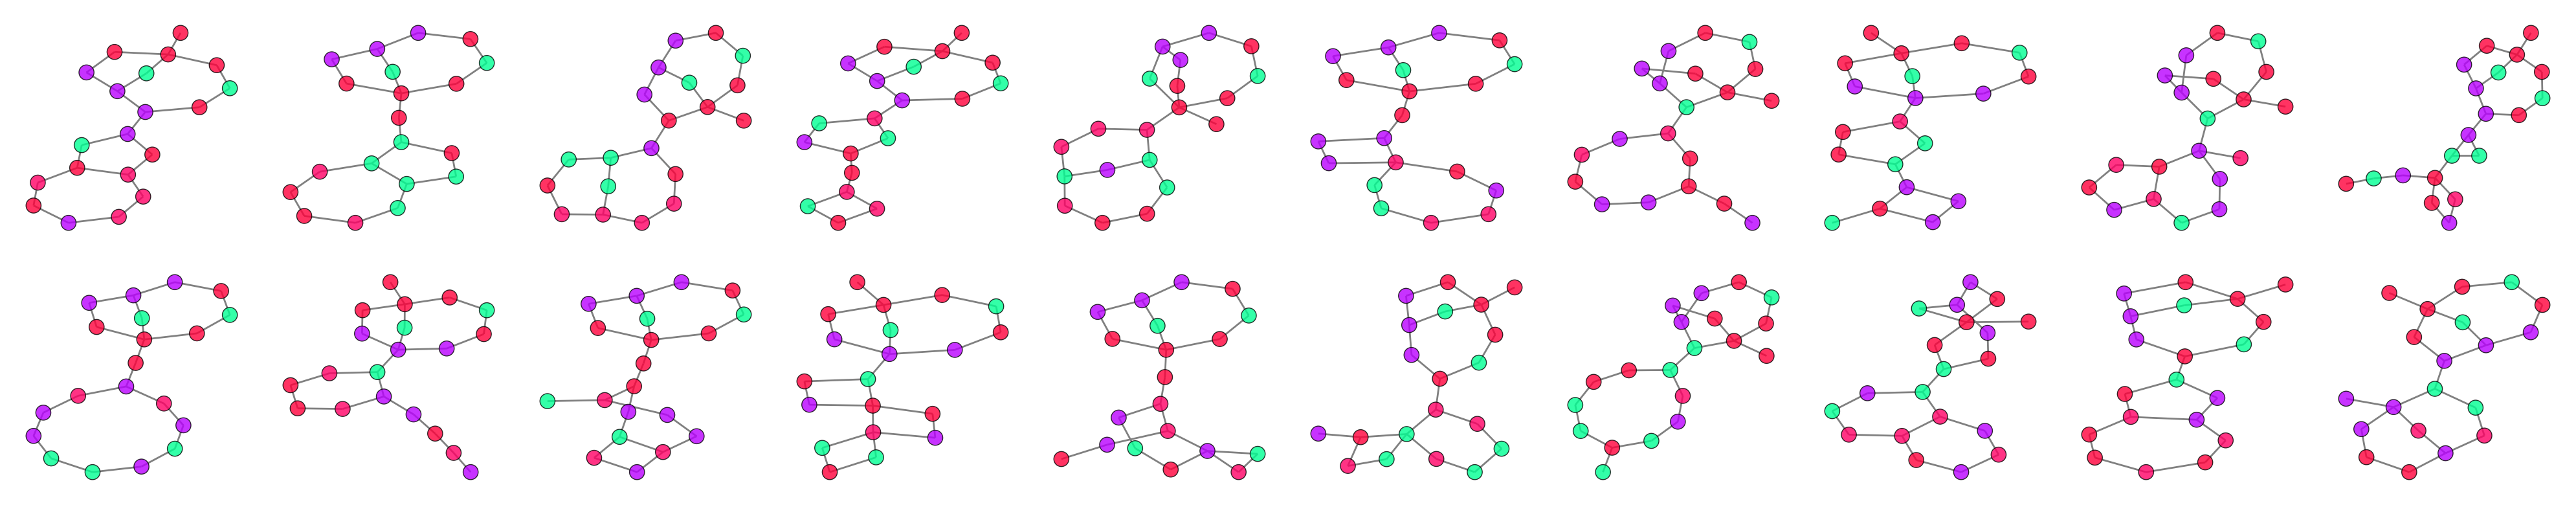

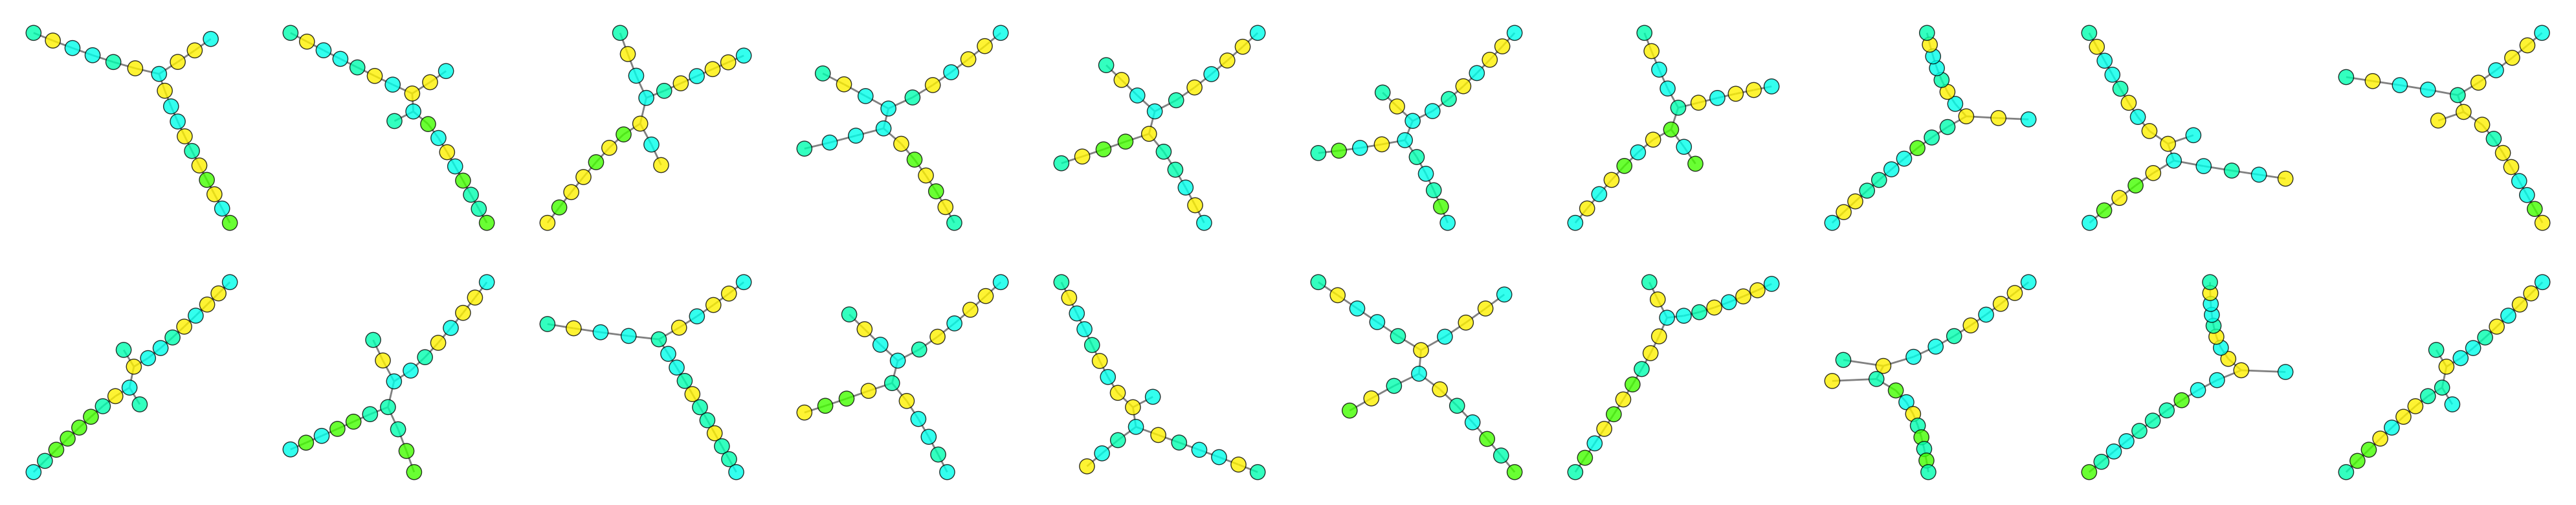

In [6]:
dataset_size = 8000
alphabet_size = 4
size = 10
graph_types = ['path', 'tree', 'cycle', 'degree', 'regular', 'dense']

graphs, targets = ArtificialGraphDatasetConstructor(
    graph_generator_target_type_pos='cycle',
    graph_generator_context_type_pos='cycle',
    graph_generator_target_type_neg='path',
    graph_generator_context_type_neg='path',
    target_size_pos=size,
    context_size_pos=size,
    n_link_edges_pos=1,
    alphabet_size_pos=alphabet_size,
    target_size_neg=size,
    context_size_neg=size,
    n_link_edges_neg=1,
    alphabet_size_neg=alphabet_size,
).sample(dataset_size // 2)

graphs, targets = offset_neg_graphs(graphs, targets, offset=alphabet_size + 1)

print(f'#graphs: {len(graphs)}')
print(f'#positive: {sum(t == 1 for t in targets)}')
print(f'#negative: {sum(t != 1 for t in targets)}')


n_graphs_per_line = 10
pos_graphs, neg_graphs = select_pos_neg(graphs, targets, n_lines=2, n_graphs_per_line=n_graphs_per_line)

from abstractgraph.display import display_graphs
display_size = 2
_ = display_graphs(pos_graphs, n_graphs_per_line=n_graphs_per_line, size=(display_size, display_size))
_ = display_graphs(neg_graphs, n_graphs_per_line=n_graphs_per_line, size=(display_size, display_size))

`TRAIN_EPOCHS` is an upper bound. Training can stop earlier because early stopping monitors validation loss and restores the best checkpoint before returning.

In [4]:
TRAIN_EPOCHS = 40
TRAIN_BATCH_SIZE = 128
TRAIN_LR = 2e-4

# The real DiGress variational-style loss is much more expensive than the
# training surrogate, so only log it every few epochs on a fixed subset.
REAL_LOSS_LOG_EVERY = 5
REAL_LOSS_SUBSET_SIZE = 256

# More diffusion steps improve the discrete denoising process but make
# both training and sampling slower.
DIFFUSION_STEPS = 150

# Wider hidden dimensions increase capacity and memory use. For this 8k
# artificial dataset, these settings are a reasonable CPU-oriented default.
HIDDEN_MLP_DIMS = {
    'X': 128, # Width of the node input/output projection MLPs before and after the transformer.
    'E': 64,  # Width of the edge projection MLPs. Kept smaller because edge tensors scale quadratically with graph size.
    'y': 64,  # Width of the global graph-channel projection MLPs used by the DiGress architecture.
}
HIDDEN_DIMS = {
    'dx': 128,      # Node hidden width inside the transformer. Larger values let the model encode richer node context.
    'de': 64,       # Edge hidden width. This controls how much capacity is dedicated to edge-type interactions.
    'dy': 64,       # Global graph hidden width for the y-channel used by the DiGress architecture.
    'n_head': 8,    # Number of attention heads. 'dx' must be divisible by this value.
    'dim_ffX': 128, # Node feed-forward width after attention. Larger values increase post-attention node mixing capacity.
    'dim_ffE': 64,  # Edge feed-forward width after attention. Larger values improve edge update expressiveness.
    'dim_ffy': 128, # Global feed-forward width for the y-channel after attention.
}

# Higher patience is more tolerant of noisy validation curves. Lower
# patience stops earlier and is cheaper but can stop too soon.
EARLY_STOPPING_PATIENCE = 5

generator = DiGressGraphGenerator(
    diffusion_steps=DIFFUSION_STEPS,
    hidden_mlp_dims=HIDDEN_MLP_DIMS,
    hidden_dims=HIDDEN_DIMS,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    real_loss_log_every=REAL_LOSS_LOG_EVERY,
    real_loss_subset_size=REAL_LOSS_SUBSET_SIZE,
).fit(
    graphs,
    targets=targets,
    epochs=TRAIN_EPOCHS,
    batch_size=TRAIN_BATCH_SIZE,
    lr=TRAIN_LR,
    device='cpu',
    seed=SEED,
    verbose=True,
)
generator

train[target=0] epoch=1/40 surrogate_loss=2.632094 real_loss=252.110764 val_real_loss=254.431286
train[target=0] epoch=2/40 surrogate_loss=2.230860 real_loss=skipped val_real_loss=239.447292
train[target=0] epoch=3/40 surrogate_loss=2.051429 real_loss=skipped val_real_loss=236.213982
train[target=0] epoch=4/40 surrogate_loss=2.016118 real_loss=skipped val_real_loss=236.973602
train[target=0] epoch=5/40 surrogate_loss=2.006640 real_loss=233.127815 val_real_loss=236.924400
train[target=0] epoch=6/40 surrogate_loss=1.936818 real_loss=skipped val_real_loss=233.883736
train[target=0] epoch=7/40 surrogate_loss=1.991968 real_loss=skipped val_real_loss=231.501259
train[target=0] epoch=8/40 surrogate_loss=1.982967 real_loss=skipped val_real_loss=234.594719
train[target=0] epoch=9/40 surrogate_loss=1.977240 real_loss=skipped val_real_loss=233.386494
train[target=0] epoch=10/40 surrogate_loss=1.957403 real_loss=231.877922 val_real_loss=235.531311
train[target=0] epoch=11/40 surrogate_loss=1.94326

pos avg_nodes=20.00, avg_edges=23.45
neg avg_nodes=20.00, avg_edges=20.15


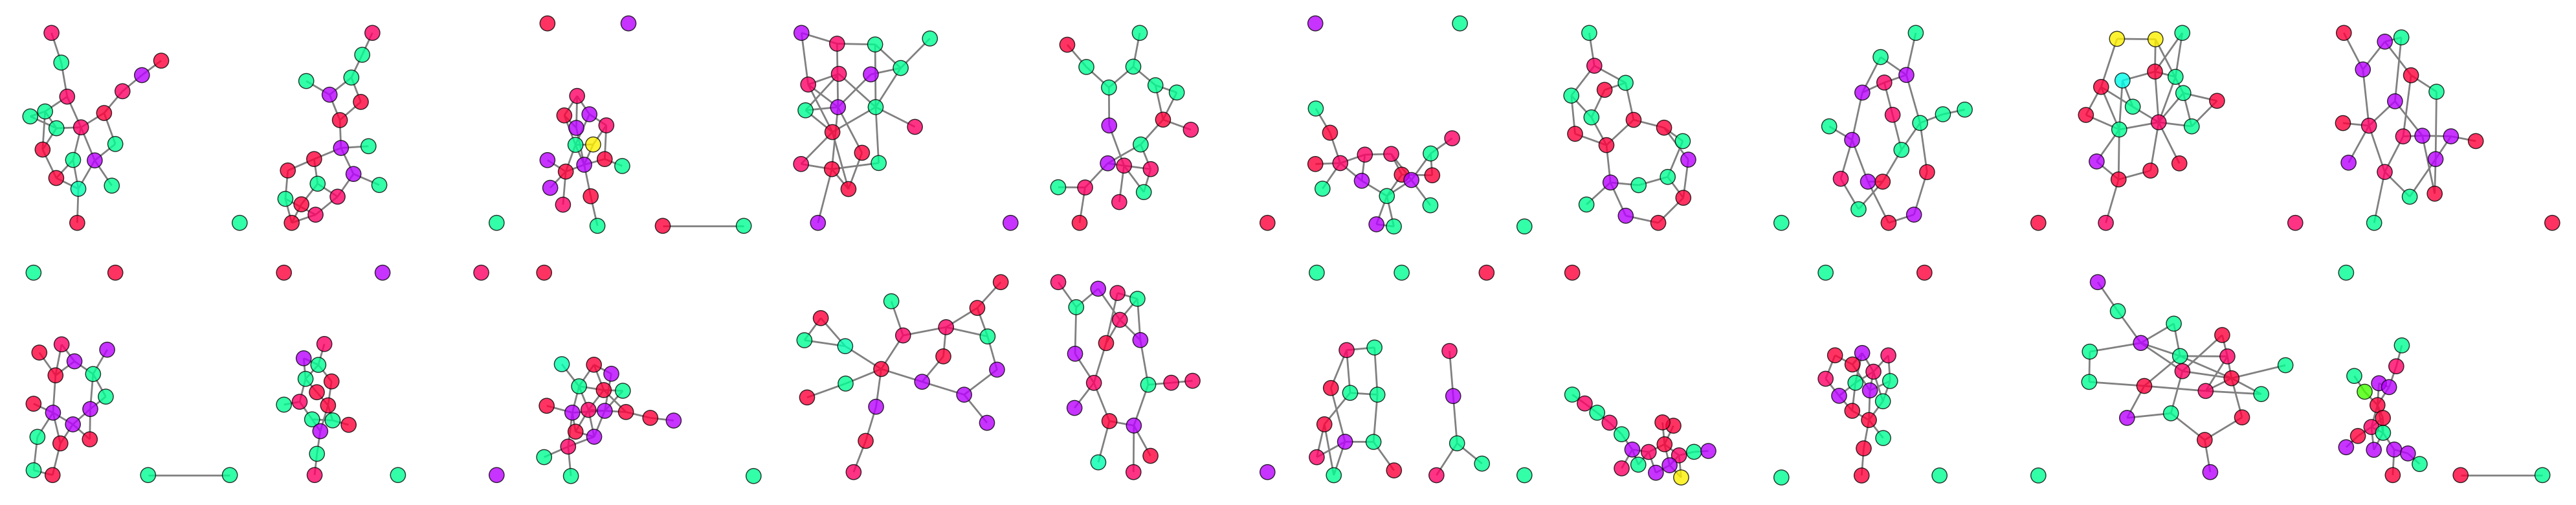

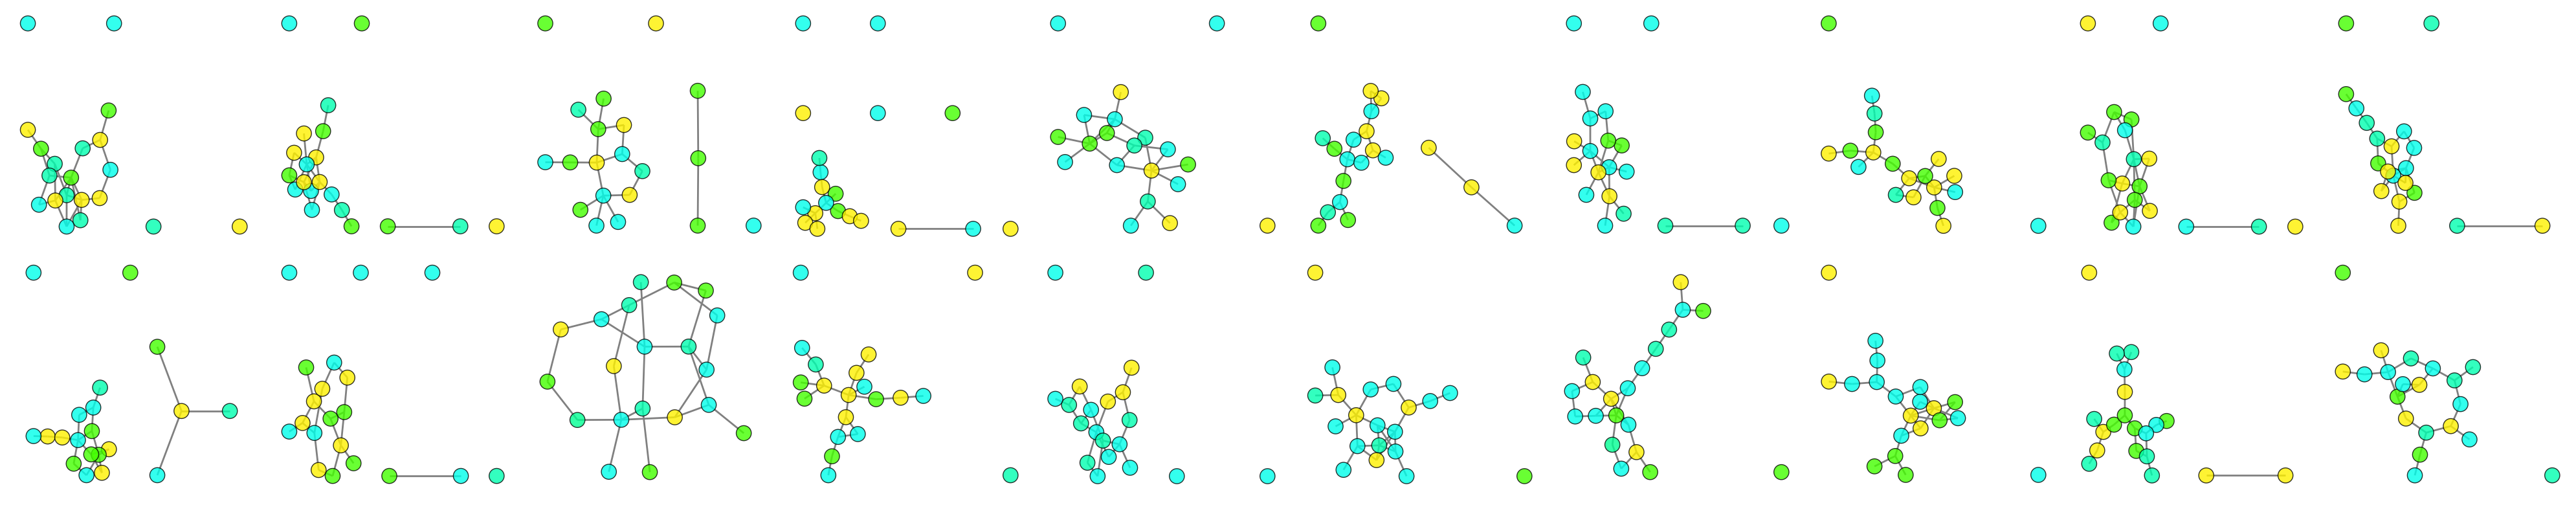

In [8]:
pos_generated_graphs = generator.generate(20, target=1, seed=SEED + 1)
neg_generated_graphs = generator.generate(20, target=0, seed=SEED + 2)
avg_nodes_pos = np.mean([g.number_of_nodes() for g in pos_generated_graphs])
avg_edges_pos = np.mean([g.number_of_edges() for g in pos_generated_graphs])
avg_nodes_neg = np.mean([g.number_of_nodes() for g in neg_generated_graphs])
avg_edges_neg = np.mean([g.number_of_edges() for g in neg_generated_graphs])
print(f'pos avg_nodes={avg_nodes_pos:.2f}, avg_edges={avg_edges_pos:.2f}')
print(f'neg avg_nodes={avg_nodes_neg:.2f}, avg_edges={avg_edges_neg:.2f}')
_ = display_graphs(pos_generated_graphs, n_graphs_per_line=n_graphs_per_line, size=(display_size, display_size))
_ = display_graphs(neg_generated_graphs, n_graphs_per_line=n_graphs_per_line, size=(display_size, display_size))